In [1]:
from casadi import *

In [2]:
model_name = 'UR5';

# States
q1_1 = SX.sym('q1_1');q1_2 = SX.sym('q1_2');q1_3 = SX.sym('q1_3');
q1_4 = SX.sym('q1_4');q1_5 = SX.sym('q1_5');q1_6 = SX.sym('q1_6');

# Controls
u1_1 = SX.sym('u1_1');u1_2 = SX.sym('u1_2');u1_3 = SX.sym('u1_3');
u1_4 = SX.sym('u1_4');u1_5 = SX.sym('u1_5');u1_6 = SX.sym('u1_6');

# acceleration controls
a1_1 = SX.sym('a1_1');a1_2 = SX.sym('a1_2');a1_3 = SX.sym('a1_3');
a1_4 = SX.sym('a1_4');a1_5 = SX.sym('a1_5');a1_6 = SX.sym('a1_6');

sym_x_short = vertcat(q1_1, q1_2, q1_3, q1_4, q1_5, q1_6);
sym_u_short = vertcat(u1_1, u1_2, u1_3, u1_4, u1_5, u1_6);
sym_a_short = vertcat(a1_1, a1_2, a1_3, a1_4, a1_5, a1_6);

sym_x = vertcat(q1_1, q1_2, q1_3, q1_4, q1_5, q1_6,
                u1_1, u1_2, u1_3, u1_4, u1_5, u1_6)
sym_u = vertcat(a1_1, a1_2, a1_3, a1_4, a1_5, a1_6)


p_human_spheres_1 = SX.sym('human_spheres_1',4,14);
p_final_cart = SX.sym('cart_goal',3);

temp_1 = horzsplit(p_human_spheres_1);
sym_p = vertcat(vcat(temp_1), p_final_cart);

Ts = 0.25 # regenerate with 0.25

q_next = sym_x_short + Ts * sym_u_short + (Ts*Ts)/2 * sym_a_short
u_next = sym_u_short + Ts * sym_a_short

x_next = vertcat(q_next, u_next)

In [3]:
## Forward kinematics
# from auto_transform
# 1 joint
# base_link_||_shoulder_link

TB1=vertcat(
horzcat(cos(q1_1), -sin(q1_1), 0,                                   0),
horzcat(sin(q1_1),  cos(q1_1), 0,                                   0),
horzcat(      0,        0, 1, 0.089159000000000002139621813057602),
horzcat(      0,        0, 0,                                   1)
);


# 2 joint
# shoulder_link_||_upper_arm_link
T12=vertcat(
horzcat(-sin(q1_2), 0,  cos(q1_2),       0),
horzcat(       0, 1,        0, 0.13585),
horzcat(-cos(q1_2), 0, -sin(q1_2),       0),
horzcat(       0, 0,        0,       1),
 );


# 3 joint
# upper_arm_link_||_forearm_link
T23=vertcat(
horzcat( cos(q1_3), 0, sin(q1_3),       0),
horzcat(       0, 1,       0, -0.1197),
horzcat(-sin(q1_3), 0, cos(q1_3),   0.425),
horzcat(       0, 0,       0,       1)
       );

# 4 joint
# forearm_link_||_wrist_1_link
T34=vertcat(
horzcat(-sin(q1_4), 0,  cos(q1_4),       0),
horzcat(       0, 1,        0,       0),
horzcat(-cos(q1_4), 0, -sin(q1_4), 0.39225),
horzcat(       0, 0,        0,       1)
       );

# 5 joint
# wrist_1_link_||_wrist_2_link
T45=vertcat(
horzcat(cos(q1_5), -sin(q1_5), 0,     0),
horzcat(sin(q1_5),  cos(q1_5), 0, 0.093),
horzcat(      0,        0, 1,     0),
horzcat(      0,        0, 0,     1)
       );

# 6 joint
# wrist_2_link_||_wrist_3_link
T56=vertcat(
horzcat( cos(q1_6), 0, sin(q1_6),       0),
horzcat(       0, 1,       0,       0),
horzcat(-sin(q1_6), 0, cos(q1_6), 0.09465),
horzcat(       0, 0,       0,       1)
       );

T6tool =  SX([
[    0.0000,   -1.0000,         0,         0],
[    1.0000,    0.0000,         0,    0.0823],
[         0,         0,    1.0000,         0],
[         0,         0,         0,    1.0000]
]);

TP1_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0679],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);

TP2_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,           0],
[         0,         0,    1.0000,      0.2125],
[         0,         0,         0,      1.0000]
]);

TP3_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0679],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);

TP4_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,           0],
[         0,         0,    1.0000,      0.1294],
[         0,         0,         0,      1.0000]
]);

TP5_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,           0],
[         0,         0,    1.0000,      0.2589],
[         0,         0,         0,      1.0000]
]);

TP6_shift = SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0465],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);

TP7_shift = SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0411],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);
# here we need to find points from j2 to end-effector
T1 = mtimes(TB1,T12);
T2 = mtimes(T1,T23);
T3 = mtimes(T2,T34); 
T4 = mtimes(T3,T45); 
T5 = mtimes(T4,T56); 
T6 = mtimes(T5,T6tool);
Tp1 = mtimes(TB1,TP1_shift);
Tp2 = mtimes(T1,TP2_shift);
Tp3 = mtimes(T2,TP3_shift);
Tp4 = mtimes(T2,TP4_shift);
Tp5 = mtimes(T2,TP5_shift);
Tp6 = mtimes(T3,TP6_shift);
Tp7 = mtimes(T5,TP7_shift);


#T_calibration = T6_1*T7end*Tend2tool;
F_cart_1 = horzcat(Tp1[0:3,3], Tp2[0:3,3], Tp3[0:3,3], Tp4[0:3,3], Tp5[0:3,3], Tp6[0:3,3], Tp7[0:3,3]);

## Velocities
Jv1_1 = jtimes(Tp1[0:3,3], sym_x_short.T, sym_u_short.T);
Jv2_1 = jtimes(Tp2[0:3,3], sym_x_short.T, sym_u_short.T);
Jv3_1 = jtimes(Tp3[0:3,3], sym_x_short.T, sym_u_short.T);
Jv4_1 = jtimes(Tp4[0:3,3], sym_x_short.T, sym_u_short.T);
Jv5_1 = jtimes(Tp5[0:3,3], sym_x_short.T, sym_u_short.T);
Jv6_1 = jtimes(Tp6[0:3,3], sym_x_short.T, sym_u_short.T);
Jv7_1 = jtimes(Tp7[0:3,3], sym_x_short.T, sym_u_short.T);


vels_array_1 = vertcat(Jv1_1[0]**2+Jv1_1[1]**2+Jv1_1[2]**2,
              Jv2_1[0]**2+Jv2_1[1]**2+Jv2_1[2]**2,
              Jv3_1[0]**2+Jv3_1[1]**2+Jv3_1[2]**2,
              Jv4_1[0]**2+Jv4_1[1]**2+Jv4_1[2]**2,
              Jv5_1[0]**2+Jv5_1[1]**2+Jv5_1[2]**2,
              Jv6_1[0]**2+Jv6_1[1]**2+Jv6_1[2]**2,
              Jv7_1[0]**2+Jv7_1[1]**2+Jv7_1[2]**2);

F_cart_vels_1 = vels_array_1;

In [4]:
## Constraints

# human avoidance 
alpha = 0.7500;            # alpha

gamma = 3.0;               # gamma for walking human to center of body
r_off_sqrd = 0.50;         # radius of offset squared

Rt1 = 0.15;
Rt2 = 0.15;
Rt3 = 0.15;
Rt4 = 0.08;
Rt5 = 0.08;
Rt6 = 0.12;
Rt7 = 0.10;
Rt = [0.15, 0.15, 0.15, 0.08, 0.08, 0.12, 0.10]; # Shperes around robot

##
h_expression_array = [];
h_lower_bounds = [];
h_upper_bounds = [];
##

calc_pose_robot_1 = F_cart_1;
calc_vels_robot_1 = F_cart_vels_1;

# table constraint
z3_1 = -Rt3 + calc_pose_robot_1[2,2];
z6_1 = -Rt6 + calc_pose_robot_1[2,5];
z7_1 = -0.05 -Rt7 + calc_pose_robot_1[2,6]; # add 5cm offset for table safety

h_expression_array = vertcat(h_expression_array, -z3_1);
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);
h_expression_array = vertcat(h_expression_array, -z6_1);
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);
h_expression_array = vertcat(h_expression_array, -z7_1);
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);

In [5]:
# stick constraint
                  # define distance to center of human torso (average of s1 s2 s14)
human_stick_x_1 = (p_human_spheres_1[0,0]+p_human_spheres_1[0,1]+p_human_spheres_1[0,13])/3; 
human_stick_y_1 = (p_human_spheres_1[1,0]+p_human_spheres_1[1,1]+p_human_spheres_1[1,13])/3;
human_stick_z_1 = (p_human_spheres_1[2,0]+p_human_spheres_1[2,1]+p_human_spheres_1[2,13])/3;
goal_dist_1 = ((p_final_cart[0]- calc_pose_robot_1[0,6])*(p_final_cart[0]- calc_pose_robot_1[0,6]) +
     (p_final_cart[1]- calc_pose_robot_1[1,6])*(p_final_cart[1]- calc_pose_robot_1[1,6]) +
     (p_final_cart[2]- calc_pose_robot_1[2,6])*(p_final_cart[2]- calc_pose_robot_1[2,6]));

dist_2_human_1 = ((human_stick_x_1 - calc_pose_robot_1[0,6])*(human_stick_x_1 - calc_pose_robot_1[0,6]) +
     (human_stick_y_1 - calc_pose_robot_1[1,6])*(human_stick_y_1 - calc_pose_robot_1[1,6]) +
     (human_stick_z_1 - calc_pose_robot_1[2,6])*(human_stick_z_1 - calc_pose_robot_1[2,6]));

d_RH_1 = exp(-gamma*(dist_2_human_1-r_off_sqrd)/(goal_dist_1));

h_expression_array = vertcat(h_expression_array, d_RH_1 );
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);

In [6]:
# human sphere constraints for velocity (hard)
for k in range(1,6+1):
    for j in range(1,14+1):  
        b2 = ((calc_pose_robot_1[0,k] - p_human_spheres_1[0,j-1])*(calc_pose_robot_1[0,k] - p_human_spheres_1[0,j-1])
           + (calc_pose_robot_1[1,k] - p_human_spheres_1[1,j-1])*(calc_pose_robot_1[1,k] - p_human_spheres_1[1,j-1])
           + (calc_pose_robot_1[2,k] - p_human_spheres_1[2,j-1])*(calc_pose_robot_1[2,k] - p_human_spheres_1[2,j-1])
           - (Rt[k-1] + p_human_spheres_1[3,j-1])*(Rt[k-1] + p_human_spheres_1[3,j-1]));
        new_line = alpha*alpha*b2;
        h_expression_array = vertcat(h_expression_array, calc_vels_robot_1[k] - new_line);
        h_lower_bounds = vertcat(h_lower_bounds, -10e8);
        h_upper_bounds = vertcat(h_upper_bounds, 0.0);
   #end
#end

In [7]:
# avoid self collision
h_expression_array = vertcat(h_expression_array, 
    (Rt1**2 + Rt7**2 - 
     ((calc_pose_robot_1[0,6]-calc_pose_robot_1[0,0])**2 +
      (calc_pose_robot_1[1,6]-calc_pose_robot_1[1,0])**2 + 
      (calc_pose_robot_1[2,6]-calc_pose_robot_1[2,0])**2)));
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);

In [8]:
h_expression_array.shape

(89, 1)

In [9]:
# set index of slack constraints
soft_indices = [x for x in range(4,(h_expression_array.shape[0]-1))];
#soft_indices = [0,1,2,3]
print(soft_indices)

[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]


In [10]:
import matplotlib.pyplot as plt

from acados_template import AcadosOcp, AcadosOcpSolver, AcadosModel, AcadosSimSolver, AcadosSim
import numpy as np
from scipy.linalg import block_diag

In [11]:
model = AcadosModel()

model.disc_dyn_expr = x_next
model.x = sym_x
model.u = sym_u
model.p = sym_p
model.name = model_name

In [12]:
# create ocp object to formulate the OCP

x0 = np.array([0.0, -2.3, -1.1, -1.2, -1.2, 0.5])
xf = np.array([3.0, -1.6, -1.7, -1.7, -1.7, 1.0])

use_cython = True

# N - maximum number of bangs
T = 2.5 # horizon length
N = 10 # Number of steps
nx = model.x.size()[0]
nu = model.u.size()[0]
# number of outputs is the concatenation of x and u
ny = nx + nu;
ny_e = nx;

# The linear cost contributions is defined through Vx, Vu and Vz
Vx = np.zeros((ny, nx));
Vx_e = np.zeros((ny_e, nx));
Vu = np.zeros((ny, nu));

Vx[0:nx,:] = np.eye(nx);
Vx_e[0:nx,:] = np.eye(nx);
Vu[nx:,:] = np.eye(nu);

Wu = 1e1*np.eye(nu);
Wx = 1e2*np.eye(nx);
W = block_diag(Wx, Wu);
W_e = Wx; # in solver holder 1000


Jbx = np.eye(nx);

Jbx_e = np.eye(nx);  

Jbu = np.eye(nu);


externtal_params = np.array([100.00,   -0.5,   0.45,   0.1500,
              100.0658,   0.4526,   0.8624,   0.2500,
              100.0844,   0.7044,   0.9207,   0.1500,
              100.2083,   0.3075,   1.0208,   0.1500,
              100.0556,   0.6289,   0.7595,   0.1500,
              100.2024,   0.2732,   0.8478,   0.1500,
              100.0267,   0.5535,   0.5983,   0.1500,
              100.1965,   0.2389,   0.6749,   0.1500,
             -100.0208,   0.3964,   0.5857,   0.1000,
              100.0546,   0.2951,   0.6132,   0.1000,
             -100.1062,   0.2444,   0.5897,   0.1300,
             -100.0998,   0.3062,   0.5387,   0.1300,
              100.1908,   0.5290,   1.0016,   0.2000,
              100.2106,   0.4602,   0.6915,   0.2500,
             0.4824, -0.1737, 0.4643])

In [13]:
ocp = AcadosOcp()
ocp.model = model

# set dimensions
ocp.dims.N = N

# set cost
ocp.parameter_values = externtal_params

# set cost
ocp.cost.cost_type = 'LINEAR_LS'
ocp.cost.cost_type_e = 'LINEAR_LS'

ocp.cost.Vx = Vx
ocp.cost.Vu = Vu
ocp.cost.Vx_e = Vx_e
ocp.cost.W = W
ocp.cost.W_e = W_e

# ocp.constraints.Jbu = Jbu # translates internaly to idxbu
ocp.constraints.lbu = np.array([-2.0,-2.0,-2.0,-2.0,-2.0,-2.0]); # -4.4
ocp.constraints.ubu = np.array([ 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]); # 4.4
ocp.constraints.idxbu = np.array([0, 1, 2, 3, 4, 5])

# ocp.constraints.Jbx = Jbx # translates internaly to idxbx
ocp.constraints.lbx =  np.array([-2*pi,-2*pi,-2*pi,-2*pi,-2*pi,-2*pi, -10, -10, -10, -10, -10, -10]); # -1.2
ocp.constraints.ubx = np.array([2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 10, 10, 10, 10, 10, 10]); # 1.2
ocp.constraints.idxbx = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

#ocp.constraints.x0 = np.array([0.0, -2.3, -1.1, -1.2, -1.2, 0.5, 0.05, 
#                               0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
ocp.constraints.idxbx_0 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
ocp.constraints.lbx_0 = np.concatenate([x0, np.zeros(6)]) #, np.zeros(6)
ocp.constraints.ubx_0 = np.concatenate([x0, np.zeros(6)])
#ocp.constraints.idxbxe_0 = np.array([6])

# ocp.constraints.Jbx_e = Jbx_e # translates internaly to idxbx_e
ocp.constraints.lbx_e = np.array([-2*pi, -2*pi, -2*pi, -2*pi, -2*pi, -2*pi]);
ocp.constraints.ubx_e = np.array([2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 2*pi]);
ocp.constraints.idxbx_e = np.array([0, 1, 2, 3, 4, 5])

# No terminal constraints
#ocp.constraints.lbx_e = xf
#ocp.constraints.ubx_e = xf
#ocp.constraints.idxbx_e = np.array([0, 1, 2, 3, 4, 5])

ocp.constraints.constr_type = 'BGH'

# set prediction horizon
ocp.solver_options.tf = T

In [14]:
W.shape

(18, 18)

In [15]:
# set index of slack constraints
# Configure constraint slack variables
with_soft = True
nh = h_expression_array.shape[0]
if with_soft:
    nsh = len(soft_indices);
    Jsh = np.zeros((nh, nsh));
    for i in range(nsh):
        Jsh[soft_indices[i],i] = 1;
    #end
    ocp.constraints.Jsh=Jsh;
    # Set cost on slack
    # L1 slack (linear term)
    ocp.cost.zl = 0 * np.ones((nsh,1));
    ocp.cost.zu = 0 * np.ones((nsh,1));
    # L2 slack (squared term)
    ocp.cost.Zl = 0.0 * np.ones((nsh,nsh));
    ocp.cost.Zu = 10000 * np.ones((nsh,nsh));
#end


In [16]:
ocp.cost.yref_0 = 20*np.ones(ny)
ocp.cost.yref = 20*np.ones(ny)
ocp.cost.yref_e = 100*np.ones(ny_e)

In [17]:
# set options
ocp.solver_options.qp_solver = 'FULL_CONDENSING_HPIPM' #'FULL_CONDENSING_HPIPM' #'PARTIAL_CONDENSING_HPIPM' # FULL_CONDENSING_QPOASES
ocp.solver_options.integrator_type = 'DISCRETE'
ocp.solver_options.nlp_solver_type = 'SQP_RTI' # SQP_RTI, SQP
ocp.solver_options.rti_phase = 0 ##
#ocp.solver_options.globalization = 'MERIT_BACKTRACKING'#'FIXED_STEP'#'MERIT_BACKTRACKING'
#ocp.solver_options.nlp_solver_max_iter = 40
#ocp.solver_options.nlp_solver_tol_stat = 1e-4
ocp.solver_options.levenberg_marquardt = 1e-5 #1e-5 #0.1
ocp.solver_options.nlp_solver_ext_qp_res = 1
ocp.solver_options.nlp_solver_step_length = 1.0
ocp.solver_options.qp_solver_cond_ric_alg = 1
ocp.solver_options.qp_solver_ric_alg = 1
ocp.solver_options.qp_solver_warm_start = 1
#ocp.solver_options.qp_solver_iter_max = 1000
ocp.code_export_directory = 'c_generated_code'
ocp.solver_options.hessian_approx = 'GAUSS_NEWTON' #'GAUSS_NEWTON'#'EXACT'
if (ocp.solver_options.hessian_approx == 'EXACT'):
    ocp.solver_options.exact_hess_constr = 1
    ocp.solver_options.exact_hess_cost = 1
    ocp.solver_options.exact_hess_dyn = 1
#end

ocp.solver_options.regularize_method = 'NO_REGULARIZE'

In [18]:
ocp.model.con_h_expr = h_expression_array
ocp.constraints.uh = np.array(h_upper_bounds.T)[0]
ocp.constraints.lh = np.array(h_lower_bounds.T)[0]

#ocp.constraints.uh = np.array(h_upper_bounds.full())
#ocp.constraints.lh = np.array(h_lower_bounds.full())


#ocp.model.con_h_expr = vertcat(u1_1, u1_2)
#ocp.constraints.lh = np.array([-10e8, -10e8, -10e8])
#ocp.constraints.uh = np.array([0.5, 0.5, 0.5])

In [19]:
np.array(h_upper_bounds.T)[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [20]:
ocp.model.con_h_expr

SX(@1=0.089159, @2=0.425, @3=sin(q1_2), @4=(@1-(@2*@3)), @5=0.39225, @6=cos(q1_2), @7=sin(q1_3), @8=cos(q1_3), @9=((@6*@7)+(@3*@8)), @10=(@4-(@5*@9)), @11=0.09465, @12=sin(q1_3), @13=cos(q1_3), @14=((@3*@12)-(@6*@13)), @15=cos(q1_4), @16=sin(q1_4), @17=0.0411, @18=cos(q1_4), @19=sin(q1_4), @20=((@9*@18)-(@14*@19)), @21=sin(q1_5), @22=(((@11*((@14*@15)+(@9*@16)))+@10)-(@17*(@20*@21))), @23=3, @24=cos(q1_1), @25=cos(q1_2), @26=(@24*@25), @27=sin(q1_2), @28=(@24*@27), @29=((@26*@8)-(@28*@7)), @30=-0.1197, @31=sin(q1_1), @32=0.13585, @33=(@32*@31), @34=(((@2*@26)-(@30*@31))-@33), @35=((@5*@29)+@34), @36=0.093, @37=((@28*@13)+(@26*@12)), @38=((@37*@19)-(@29*@18)), @39=cos(q1_5), @40=(((@35-(@36*@31))-(@11*((@37*@15)+(@29*@16))))-(@17*((@38*@21)+(@31*@39)))), @41=cos(q1_1), @42=sin(q1_1), @43=(@42*@27), @44=(@42*@25), @45=((@43*@13)+(@44*@12)), @46=((@44*@8)-(@43*@7)), @47=((@45*@19)-(@46*@18)), @48=(@32*@41), @49=(((@30*@41)+(@2*@44))+@48), @50=((@5*@46)+@49), @51=((@17*((@41*@39)-(@47*@21)

In [21]:
h_expression_array.shape

(89, 1)

In [22]:
ocp.model.con_h_expr.shape

(89, 1)

In [23]:

ocp.model.p = sym_p

ocp.parameter_values = np.array([100.00,   -0.5,   0.45,   0.1500,
              100.0658,   0.4526,   0.8624,   0.2500,
              100.0844,   0.7044,   0.9207,   0.1500,
              100.2083,   0.3075,   1.0208,   0.1500,
              100.0556,   0.6289,   0.7595,   0.1500,
              100.2024,   0.2732,   0.8478,   0.1500,
              100.0267,   0.5535,   0.5983,   0.1500,
              100.1965,   0.2389,   0.6749,   0.1500,
             -100.0208,   0.3964,   0.5857,   0.1000,
              100.0546,   0.2951,   0.6132,   0.1000,
             -100.1062,   0.2444,   0.5897,   0.1300,
             -100.0998,   0.3062,   0.5387,   0.1300,
              100.1908,   0.5290,   1.0016,   0.2000,
              100.2106,   0.4602,   0.6915,   0.2500,
             0.4824, -0.1737, 0.4643])

In [24]:
if use_cython:
    AcadosOcpSolver.generate(ocp, json_file='acados_ocp.json')
    AcadosOcpSolver.build(ocp.code_export_directory, with_cython=True)
    ocp_solver = AcadosOcpSolver.create_cython_solver('acados_ocp.json')
else: # ctypes
    ## Note: skip generate and build assuming this is done before (in cython run)
    ocp_solver = AcadosOcpSolver(ocp, json_file='acados_ocp.json', build=False, generate=False)

ocp_solver.reset()

make: *** No rule to make target 'clean_all'.  Stop.


cc -fPIC -std=c99   -O2 -I/home/chri/Documents/acados/include -I/home/chri/Documents/acados/include/acados -I/home/chri/Documents/acados/include/blasfeo/include -I/home/chri/Documents/acados/include/hpipm/include  -c -o UR5_constraints/UR5_constr_h_fun_jac_uxt_zt.o UR5_constraints/UR5_constr_h_fun_jac_uxt_zt.c
cc -fPIC -std=c99   -O2 -I/home/chri/Documents/acados/include -I/home/chri/Documents/acados/include/acados -I/home/chri/Documents/acados/include/blasfeo/include -I/home/chri/Documents/acados/include/hpipm/include  -c -o UR5_constraints/UR5_constr_h_fun.o UR5_constraints/UR5_constr_h_fun.c
cc -fPIC -std=c99   -O2 -I/home/chri/Documents/acados/include -I/home/chri/Documents/acados/include/acados -I/home/chri/Documents/acados/include/blasfeo/include -I/home/chri/Documents/acados/include/hpipm/include  -c -o acados_solver_UR5.o acados_solver_UR5.c
cc -fPIC -std=c99   -O2 -I/home/chri/Documents/acados/include -I/home/chri/Documents/acados/include/acados -I/home/chri/Documents/acados/i

In file included from /home/chri/.local/lib/python3.10/site-packages/numpy/core/include/numpy/ndarraytypes.h:1940,
                 from /home/chri/.local/lib/python3.10/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /home/chri/.local/lib/python3.10/site-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from acados_ocp_solver_pyx.c:1230:
/home/chri/.local/lib/python3.10/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~


cc  -shared \
-o acados_ocp_solver_pyx.so \
-Wl,-rpath=/home/chri/Documents/acados/lib \
acados_ocp_solver_pyx.o \
/home/chri/CHRI_2025/Time_optimal_baseline/solvers/c_generated_code/libacados_ocp_solver_UR5.so \
-L/home/chri/Documents/acados/lib -lacados -lhpipm -lblasfeo -lm


0

In [25]:
ocp.constraints.lbx

array([ -6.28318531,  -6.28318531,  -6.28318531,  -6.28318531,
        -6.28318531,  -6.28318531, -10.        , -10.        ,
       -10.        , -10.        , -10.        , -10.        ])

In [26]:
len(ocp.parameter_values)

59

In [27]:
import time

for i, tau in enumerate(np.linspace(0, 1, N)):
    ocp_solver.set(i, 'x', np.append((1-tau)*x0 + tau*xf,np.array([0.0,0.0,0.0,0.0,0.0,0.0])))
    ocp_solver.set(i, 'u', np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0]))

simX = np.zeros((N+1, nx))
simU = np.zeros((N, nu))

In [28]:
start = time.time()
status = ocp_solver.solve()
print('status',status,time.time()-start)

status 0 0.04717230796813965


In [29]:
#if status != 0:
#    ocp_solver.print_statistics()
#    raise Exception(f'acados returned status {status}.')

ocp_solver.print_statistics()
    
# get solution
for i in range(N):
    simX[i,:] = ocp_solver.get(i, "x")
    simU[i,:] = ocp_solver.get(i, "u")
simX[N,:] = ocp_solver.get(N, "x")

dts = simU[:, 1]

print("acados solved OCP successfully, creating integrator to simulate the solution")


acados solved OCP successfully, creating integrator to simulate the solutioniter	qp_stat	qp_iter
0	0	0	0	0	0	0	
1	2	50	0	0	0	0	



In [30]:
import matplotlib.pyplot as plt

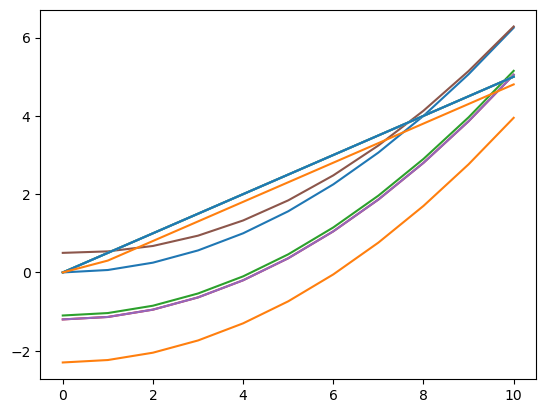

In [31]:
plt.plot(simX)
plt.show()

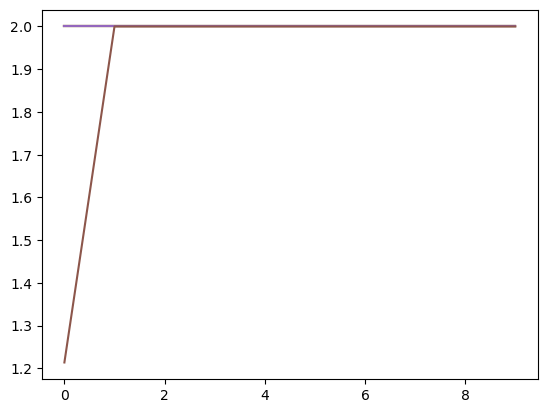

In [32]:
plt.plot(simU)
plt.show()